先尝试用均匀分布模型来拟合样本：

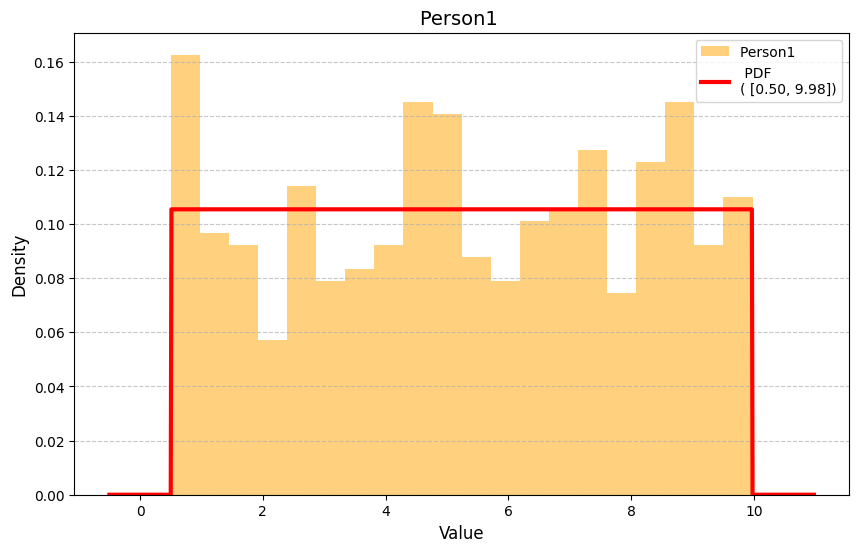

拟合结果：
最小值 (a): 0.5000
最大值 (b): 9.9800
区间长度 (b-a): 9.4800


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

df = pd.read_csv('envelopes.csv')



# 2. 数据清洗：剔除最后一行 "Total"
df_clean = df.iloc[:-1].copy()

# 确保 Person1 列为浮点数类型
person1_values = df_clean['Person1'].astype(float)

# 3. 使用均匀分布拟合数据
# uniform.fit 返回 (loc, scale)，其中 loc 是起点 a，scale 是区间长度 (b - a)
a_fit, scale_fit = uniform.fit(person1_values)
b_fit = a_fit + scale_fit

# 4. 绘图
plt.figure(figsize=(10, 6))

# 绘制直方图（density=True 保证纵坐标为概率密度）
plt.hist(person1_values, bins=20, density=True, alpha=0.5, color='orange', label='Person1 ')

# 生成拟合的 PDF 曲线
x = np.linspace(a_fit - 1, b_fit + 1, 1000)
pdf = uniform.pdf(x, loc=a_fit, scale=scale_fit)
plt.plot(x, pdf, 'r-', lw=3, label=f' PDF\n( [{a_fit:.2f}, {b_fit:.2f}])')

# 设置图表细节
plt.title('Person1 ', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 输出拟合参数
print(f"拟合结果：")
print(f"最小值 (a): {a_fit:.4f}")
print(f"最大值 (b): {b_fit:.4f}")
print(f"区间长度 (b-a): {scale_fit:.4f}")

用KS检验计算D值和P值，其中P值用蒙特卡洛模拟5000次后计算真实D值的排位来修正：

Executing Monte Carlo Simulation (5000 iterations)...


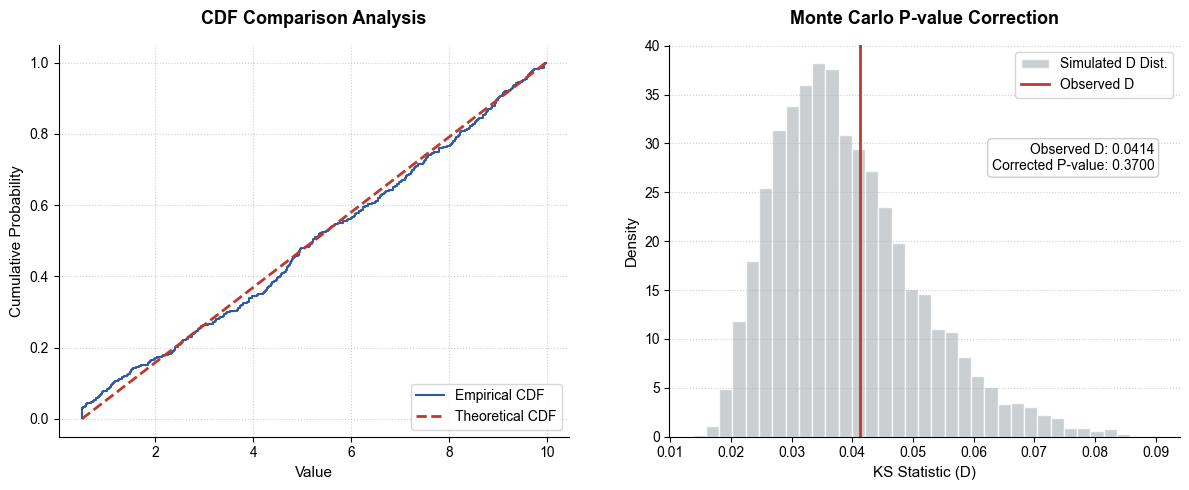

Fit Results: a=0.500, b=9.980
Corrected P-value: 0.3700


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, kstest
import io

# 1. 数据准备
# 假设 df 已经由之前的步骤读入
df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person1'].astype(float).values
n_samples = len(person1_data)

# 2. 参数估计与 KS 统计量计算
a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (优化比例与外观)
# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 调整画布比例为 12:5，增加 dpi 使图像更清晰
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# --- Left Plot: ECDF vs Theoretical CDF ---
sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
# 去掉上方和右方线条，更美观
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right Plot: Monte Carlo Distribution of D ---
# 使用稍微透明的条形，并调整颜色
ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

# 动态标注 P 值
ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

# 优化标注文本的位置和样式
text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 调整子图间的距离，防止标签重叠
plt.tight_layout(w_pad=4.0)
plt.show()

# 控制台输出
print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

P > 0.5，接受均匀分布模型和参数。

但是我们发现：后续几个人领到的金额出现了明显的拖尾效应。在散点图上可以观察到后面几个人的样本明显向更大的金额上扩散，且尾端分布呈现出递减的形状。此时继续用均匀分布模型明显不再合适，比如我们分析第三个人的样本：

Executing Monte Carlo Simulation (5000 iterations)...


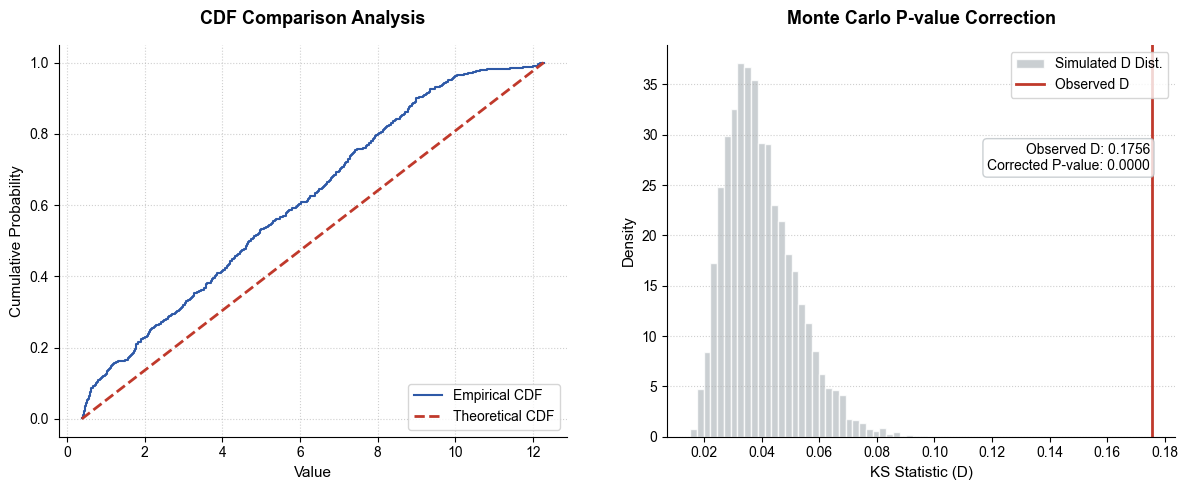

Fit Results: a=0.380, b=12.280
Corrected P-value: 0.0000


In [8]:
# 1. 数据准备
# 假设 df 已经由之前的步骤读入
df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person3'].astype(float).values
n_samples = len(person1_data)

# 2. 参数估计与 KS 统计量计算
a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (优化比例与外观)
# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 调整画布比例为 12:5，增加 dpi 使图像更清晰
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# --- Left Plot: ECDF vs Theoretical CDF ---
sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
# 去掉上方和右方线条，更美观
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right Plot: Monte Carlo Distribution of D ---
# 使用稍微透明的条形，并调整颜色
ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

# 动态标注 P 值
ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

# 优化标注文本的位置和样式
text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 调整子图间的距离，防止标签重叠
plt.tight_layout(w_pad=4.0)
plt.show()

# 控制台输出
print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

可以看到P值很小。接下来我们换一个模型重新拟合